# Regresion logistica - Titanic

Objetivo: entrenar el modelo y evaluar con matriz de confusion, accuracy, precision y recall.

## 1) Librerias

In [1]:
!pip install pandas matplotlib seaborn scikit-learn

In [3]:
# Datos
import pandas as pd


In [4]:
# Calculo numerico
import numpy as np


In [5]:
# Modelo


In [7]:
import statsmodels.api as sm

In [8]:
# Metricas
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report


## 2) Cargar datos

In [9]:
# Leer archivo
titanic = pd.read_csv("titanic.csv")


In [10]:
# Vista rapida
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# Tipos de columnas
titanic.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 3) Preparar datos

In [12]:
# Convertir tipos
titanic["Survived"] = titanic["Survived"].astype(int)


In [13]:
# Convertir tipos
titanic["Sex"] = titanic["Sex"].astype("category")


In [14]:
# Convertir tipos
titanic["Pclass"] = titanic["Pclass"].astype("category")


In [15]:
# Eliminar faltantes clave
datos_modelo = titanic.dropna(subset=["Age", "Embarked"])


In [16]:
# Seleccionar variables
datos_modelo = datos_modelo[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]


In [17]:
# Resumen
datos_modelo.describe(include="all")


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,712.000000,712.0,712,712.000000,712.000000,712.000000,712.000000,712
unique,NaN,3.0,2,NaN,NaN,NaN,NaN,3
top,NaN,3.0,male,NaN,NaN,NaN,NaN,S
freq,NaN,355.0,453,NaN,NaN,NaN,NaN,554
mean,0.404494,NaN,NaN,29.642093,0.514045,0.432584,34.567251,NaN
std,0.491139,NaN,NaN,14.492933,0.930692,0.854181,52.938648,NaN
min,0.000000,NaN,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,0.000000,NaN,NaN,20.000000,0.000000,0.000000,8.050000,NaN
50%,0.000000,NaN,NaN,28.000000,0.000000,0.000000,15.645850,NaN
75%,1.000000,NaN,NaN,38.000000,1.000000,1.000000,33.000000,NaN


In [68]:
datos_modelo["Survived"].mean()

np.float64(0.4044943820224719)

## 4) Separar entrenamiento y prueba (80/20)

In [18]:
# Muestreo reproducible
np.random.seed(123)


In [19]:
# Indices de entrenamiento
indices = np.random.choice(datos_modelo.index, size=int(0.8 * len(datos_modelo)), replace=False)


In [20]:
# Conjuntos
entrenamiento = datos_modelo.loc[indices].copy()
prueba = datos_modelo.drop(indices).copy()


In [21]:
len(entrenamiento), len(prueba)

(569, 143)

## 5) Crear matriz de entrada

In [22]:
# Variables X entrenamiento
X_train = entrenamiento[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()


In [23]:
# Variable y entrenamiento
y_train = entrenamiento["Survived"].copy()


In [24]:
# Variables X prueba
X_test = prueba[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()


In [26]:
# Variable y prueba
y_test = prueba["Survived"].copy()


In [27]:
# Alinear columnas
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


In [29]:
data_train = pd.concat([X_train, y_train], axis=1)
data_test = pd.concat([X_test, y_test], axis=1)

## 6) Entrenar modelo

In [57]:
data_train["Pclass"] = data_train["Pclass"].astype("category")
data_train["Pclass_int"] = data_train["Pclass"].astype("int")

data_train["Sex"] = data_train["Sex"].astype("category")
data_train["Sex_int"] = data_train["Sex"].map({"male": 1, "female": 0}).astype(int)

In [60]:
logit_res = sm.formula.logit("Survived ~ Age + C(Pclass) + C(Sex)", data=data_train).fit()
logit_res.summary()

Optimization terminated successfully.
         Current function value: 0.446272
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  569
Model:                          Logit   Df Residuals:                      564
Method:                           MLE   Df Model:                            4
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  0.3372
Time:                        01:09:56   Log-Likelihood:                -253.93
converged:                       True   LL-Null:                       -383.11
Covariance Type:            nonrobust   LLR p-value:                 1.032e-54
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.5932      0.440      8.163      0.000       2.730       4.456
C(Pclass)[T.2]    -1.1940      0.309     -3.861      0.000      -1.800      -0.588
C(Pclass)[T.3]    -2.5257      0.312     -8.096      0.000      -3.137      -1.914
C(Sex)[T.male]    -2.6020      0.235    -11.076      0.000      -3.062      -2.142
Age               -0.0331      0.009     -3.822      0.000      -0.050      -0.016
==================================================================================
"""

In [62]:
logit_res_int = sm.formula.logit("Survived ~ Age + Pclass_int + Sex_int", data=data_train).fit()
logit_res_int.summary()

Optimization terminated successfully.
         Current function value: 0.446339
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  569
Model:                          Logit   Df Residuals:                      565
Method:                           MLE   Df Model:                            3
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  0.3371
Time:                        01:10:06   Log-Likelihood:                -253.97
converged:                       True   LL-Null:                       -383.11
Covariance Type:            nonrobust   LLR p-value:                 1.060e-55
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8905      0.556      8.793      0.000       3.800       5.981
Age           -0.0332      0.009     -3.843      0.000      -0.050      -0.016
Pclass_int    -1.2681      0.155     -8.187      0.000      -1.572      -0.965
Sex_int       -2.6018      0.235    -11.084      0.000      -3.062      -2.142
==============================================================================
"""

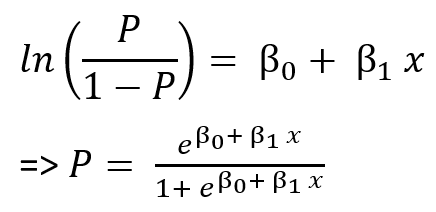

# Formula log-odd ratio para modelo sin categoricas
ln(P/1-P) = 4.8905 - 0.0332 x Age - 1.2681 x Pclass_int - 2.6018 x Sex_int

suma_lineal = 4.8905 - 0.0332 x Age - 1.2681 x Pclass_int - 2.6018 x Sex_int
P(survived=1) = exp(suma_lineal) / (1 + exp(suma_lineal))

# Formula log-odd ratio para modelo con categoricas
ln(P/1-P) = 3.5932 - 1.1940 x [Pclass == 2] - 2.5257 x [Pclass == 3] - 2.6020 [Sex == male] - 0.0331 x Age

## 7) Predecir

In [69]:
# Probabilidades entrenamiento
predicciones_train = logit_res.predict(data_train)
predicciones_clase_train = (predicciones_train >= 0.4).astype(int)
predicciones_test = logit_res.predict(data_test)
predicciones_clase_test = (predicciones_test >= 0.4).astype(int)

In [70]:
accuracy_score(data_train["Survived"], predicciones_clase_train)

0.7961335676625659

In [71]:
accuracy_score(y_test, predicciones_clase_test)

0.8111888111888111

## 8) Evaluacion

In [72]:
# Matriz de confusion entrenamiento
cm = confusion_matrix(y_train, predicciones_clase_train)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,268,73
Real_1,43,185


In [73]:
# Reporte de clasificacion
print(classification_report(y_train, predicciones_clase_train, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.8617    0.7859    0.8221       341
           1     0.7171    0.8114    0.7613       228

    accuracy                         0.7961       569
   macro avg     0.7894    0.7987    0.7917       569
weighted avg     0.8038    0.7961    0.7977       569



In [ ]:
# Matriz de confusion prueba
cm = confusion_matrix(y_test, predicciones_clase_test)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


In [ ]:
# Reporte de clasificacion
print(classification_report(y_test, predicciones_clase_test, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.7935    0.8795    0.8343        83
           1     0.8039    0.6833    0.7387        60

    accuracy                         0.7972       143
   macro avg     0.7987    0.7814    0.7865       143
weighted avg     0.7979    0.7972    0.7942       143



In [ ]:
# Accuracy entrenamiento
accuracy_score(y_train, predicciones_clase_train)


0.8101933216168717

In [ ]:
# Precision entrenamiento
precision_score(y_train, predicciones_clase_train, zero_division=0)


0.7912621359223301

In [ ]:
# Recall entrenamiento
recall_score(y_train, predicciones_clase_train, zero_division=0)


0.7149122807017544

In [ ]:
# Accuracy prueba
accuracy_score(y_test, predicciones_clase_test)


0.7972027972027972

In [ ]:
# Precision prueba
precision_score(y_test, predicciones_clase_test, zero_division=0)


0.803921568627451

In [ ]:
# Recall prueba
recall_score(y_test, predicciones_clase_test, zero_division=0)


0.6833333333333333

In [45]:
# Tabla resumen
resumen_metricas = pd.DataFrame({
    "Metrica": ["Accuracy", "Precision", "Recall"],
    "Entrenamiento": [
        accuracy_score(y_train, pred_train),
        precision_score(y_train, pred_train, zero_division=0),
        recall_score(y_train, pred_train, zero_division=0),
    ],
    "Prueba": [
        accuracy_score(y_test, pred_test),
        precision_score(y_test, pred_test, zero_division=0),
        recall_score(y_test, pred_test, zero_division=0),
    ]
})
resumen_metricas


,Metrica,Entrenamiento,Prueba
0,Accuracy,0.810193,0.797203
1,Precision,0.791262,0.803922
2,Recall,0.714912,0.683333
